# Task 5: Wine Quality Prediction

## Objective
Predict wine quality based on physicochemical properties, using the Wine Quality dataset (Kaggle) containing measurements such as acidity, sugar, chlorides, sulphur dioxide levels, density, pH, sulphates, and alcohol content.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('WineQT.csv')

print(df.shape)
df.head()

(1143, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


## Data Overview

Checking data types and missing values before proceeding.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [4]:
df['quality'].value_counts().sort_index()

quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

No missing values across all 1143 rows. The `Id` column is just a row identifier and will be dropped before modeling, as it carries no predictive information.

## Exploratory Data Analysis

Wine quality scores range from 3 to 8, with most wines concentrated around 5-6, showing a fairly imbalanced distribution.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_27256\3763352225.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=df, palette='viridis')


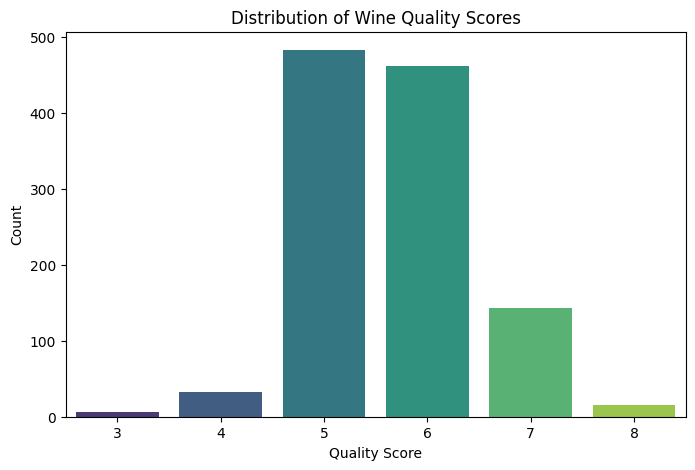

In [5]:
plt.figure(figsize=(8,5))
sns.countplot(x='quality', data=df, palette='viridis')
plt.title('Distribution of Wine Quality Scores')
plt.xlabel('Quality Score')
plt.ylabel('Count')
plt.show()

### Correlation with Wine Quality

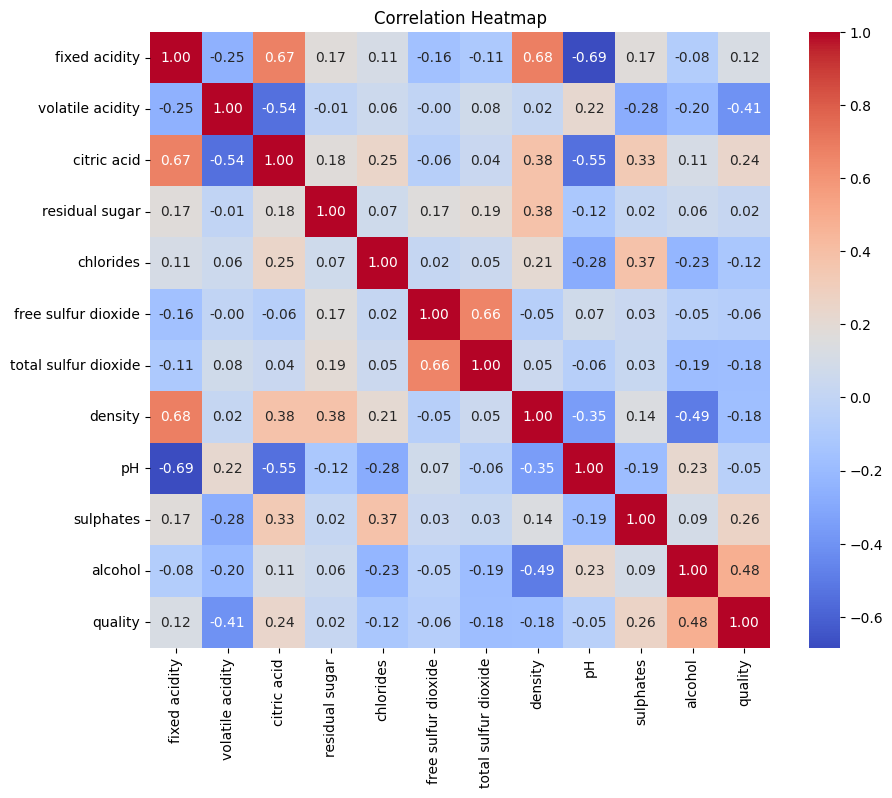

In [6]:
plt.figure(figsize=(10,8))
correlation = df.drop('Id', axis=1).corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

Alcohol content shows the strongest positive correlation with quality (0.48), while volatile acidity shows the strongest negative correlation (-0.41) — higher volatile acidity (associated with a vinegary taste) tends to lower perceived quality. Sulphates (0.26) and citric acid (0.24) show moderate positive correlations as well.

## Data Preparation

Dropping the `Id` column (not predictive) and separating features from the target variable.

In [7]:
df = df.drop('Id', axis=1)

X = df.drop('quality', axis=1)
y = df['quality']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (1143, 11)
Target shape: (1143,)


## Train/Test Split

Splitting into training and test sets (80/20 split).

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (914, 11)
Test set: (229, 11)


## Model Training

Training a Random Forest Classifier, which handles multi-class classification well and doesn't require feature scaling.

In [9]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model trained successfully.")

Model trained successfully.


## Model Evaluation

Evaluating performance using accuracy score and a detailed classification report.

In [10]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7162

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.74      0.85      0.79        97
           6       0.69      0.74      0.71        92
           7       0.74      0.48      0.58        29
           8       0.00      0.00      0.00         3

    accuracy                           0.72       229
   macro avg       0.36      0.34      0.35       229
weighted avg       0.68      0.72      0.69       229



C:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

The model achieved 71.6% accuracy overall. Performance is strong on the common quality scores (5 and 6, which make up the bulk of the data), but the model fails to correctly identify the rare classes (3, 4, 8) since there are too few training examples of each — this is a direct consequence of the class imbalance seen earlier.

### Feature Importance

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_27256\2961824097.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importances, palette='viridis')


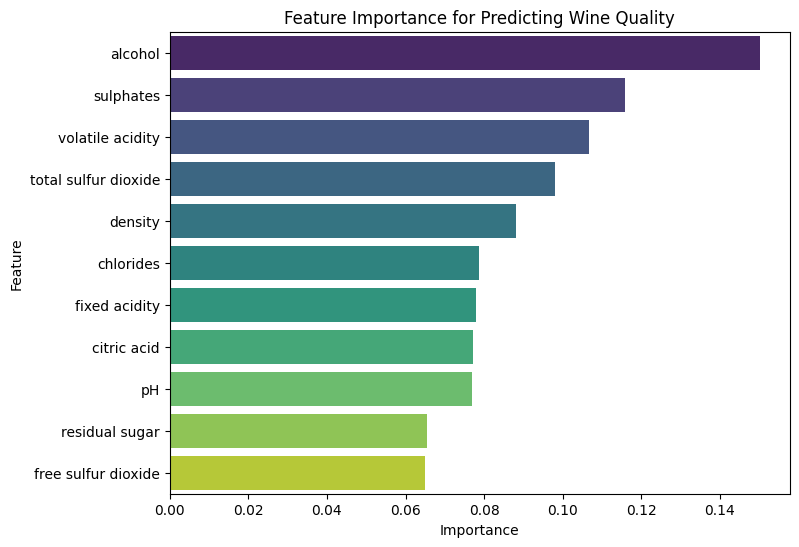

In [11]:
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x='Importance', y='Feature', data=importances, palette='viridis')
plt.title('Feature Importance for Predicting Wine Quality')
plt.show()

## Conclusions

- Trained a Random Forest Classifier to predict wine quality (scored 3-8) from 11 physicochemical properties.
- The model achieved 71.6% accuracy on the test set.
- Alcohol content and sulphates were the most important predictors, consistent with their strong correlations seen during EDA.
- Volatile acidity was the strongest negative predictor — wines with higher volatile acidity tend to be rated lower, likely due to the vinegary taste it causes.
- The dataset is heavily imbalanced (most wines scored 5 or 6), which limited the model's ability to correctly classify rare quality scores (3, 4, 8). Techniques like oversampling (SMOTE) or treating this as a binary "good vs. not good" classification problem could improve performance on the minority classes in future iterations.